# Retail & Marketing Analytics: Customer Segmentation & Growth Strategy

**Objective:** Segment customers using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to drive targeted marketing campaigns.

**Dataset:** Synthetic e-commerce transactions modeled after the UCI *Online Retail II* dataset (~70K transactions, 2,500 customers, 12 months).

**Business Value:** Identify high-value customers, prevent churn, and design segment-specific marketing strategies to maximize CLV (Customer Lifetime Value).

## Pipeline Stages
1. Data Loading & Cleaning
2. Exploratory Data Analysis
3. RFM Feature Engineering
4. K-Means Clustering
5. Segment Profiling
6. Marketing Strategy Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('../data/online_retail.csv', parse_dates=['InvoiceDate'])
print(f'Shape: {df.shape}')
df.head()

Shape: (70240, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,507714,84029E,RED WOOLLY HOTTIE WHITE HEART,13,2024-01-22 16:03:00,3.41,C11215,United Kingdom
1,511970,84879,ASSORTED COLOUR BIRD ORNAMENT,7,2024-01-03 16:07:00,1.63,C11897,United Kingdom
2,503886,71053,WHITE METAL LANTERN,9,2024-02-05 14:46:00,3.31,C10599,United Kingdom
3,505119,84969,BOX OF 6 ASSORTED COLOUR TEASPOONS,40,2024-07-27 14:03:00,4.11,C10794,United Kingdom
4,503453,22189,CREAM HEART CARD HOLDER,19,2024-02-05 19:34:00,7.17,C10521,United Kingdom


In [3]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nNegative quantities (returns): {(df["Quantity"]<0).sum()}')
print(f'Zero/negative prices: {(df["UnitPrice"]<=0).sum()}')

Missing values:
InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1405
Country           0
dtype: int64

Negative quantities (returns): 1054
Zero/negative prices: 0


In [4]:
# Clean: drop missing CustomerID, remove returns and invalid prices
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'Cleaned shape: {df_clean.shape}')
print(f'Total revenue: ${df_clean["TotalAmount"].sum():,.2f}')

Cleaned shape: (67802, 9)
Total revenue: $4,318,248.25


## 2. Exploratory Data Analysis

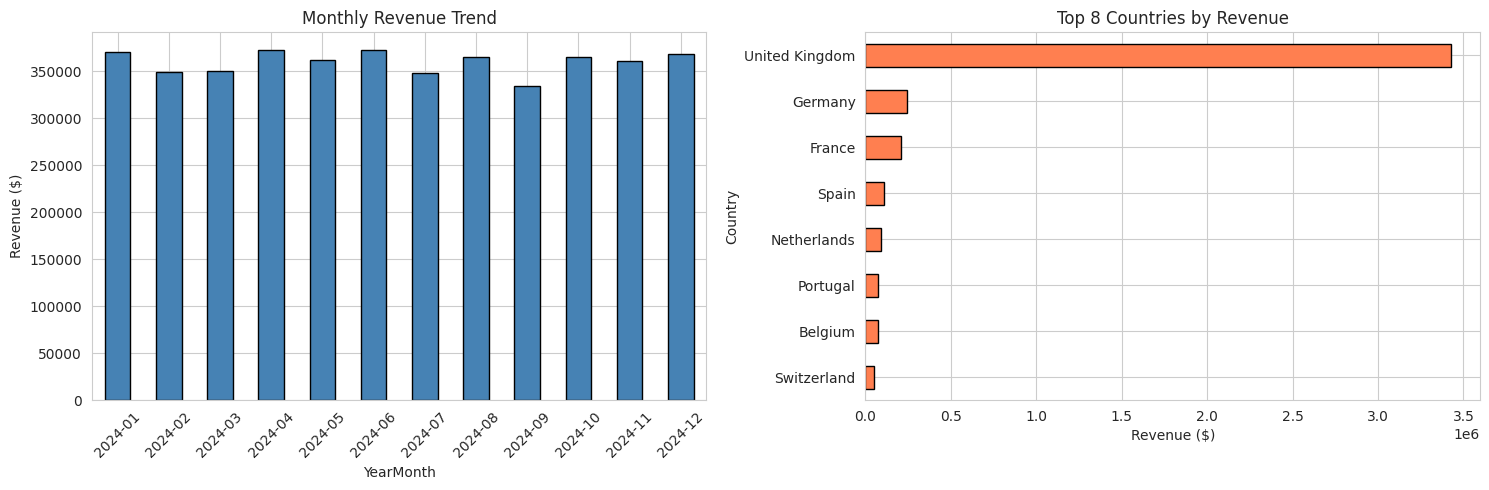

In [5]:
# Monthly revenue trend
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
monthly = df_clean.groupby('YearMonth')['TotalAmount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
monthly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

country_rev = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=True).tail(8)
country_rev.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 8 Countries by Revenue')
axes[1].set_xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('../outputs/eda_revenue.png', dpi=100, bbox_inches='tight')
plt.show()

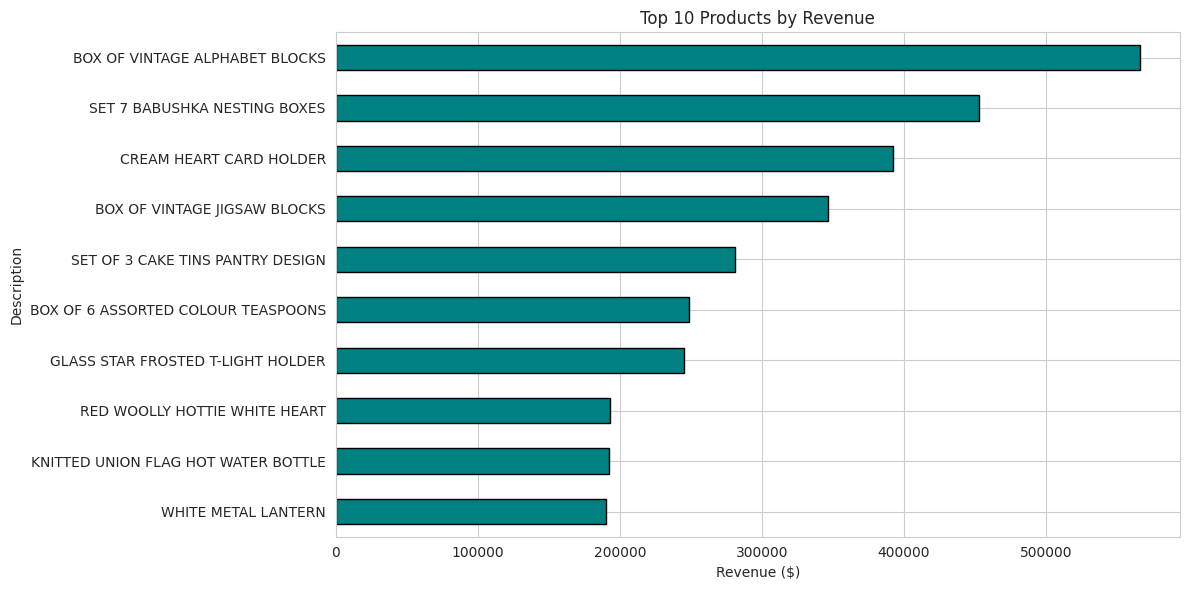

,units_sold,revenue
Description,,
BOX OF VINTAGE ALPHABET BLOCKS,56926,565859.23
SET 7 BABUSHKA NESTING BOXES,59170,452559.43
CREAM HEART CARD HOLDER,56474,392158.14
BOX OF VINTAGE JIGSAW BLOCKS,58157,346178.08
SET OF 3 CAKE TINS PANTRY DESIGN,56746,280935.74
BOX OF 6 ASSORTED COLOUR TEASPOONS,58566,248918.08
GLASS STAR FROSTED T-LIGHT HOLDER,57643,244844.71
RED WOOLLY HOTTIE WHITE HEART,57038,193451.90
KNITTED UNION FLAG HOT WATER BOTTLE,56787,192579.18


In [6]:
# Top products
top_products = df_clean.groupby('Description').agg(
    units_sold=('Quantity', 'sum'),
    revenue=('TotalAmount', 'sum')
).sort_values('revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_products['revenue'].sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('../outputs/top_products.png', dpi=100, bbox_inches='tight')
plt.show()
top_products

## 3. RFM Feature Engineering

In [7]:
# Snapshot date = day after last transaction
snapshot_date = df_clean['InvoiceDate'].max() + timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
rfm.head()

Snapshot date: 2025-01-01 19:57:00
RFM table shape: (2497, 4)


,CustomerID,Recency,Frequency,Monetary
0,C10000,86,7,1325.84
1,C10001,179,1,31.75
2,C10002,186,2,624.15
3,C10003,7,3,407.42
4,C10004,94,12,2097.03


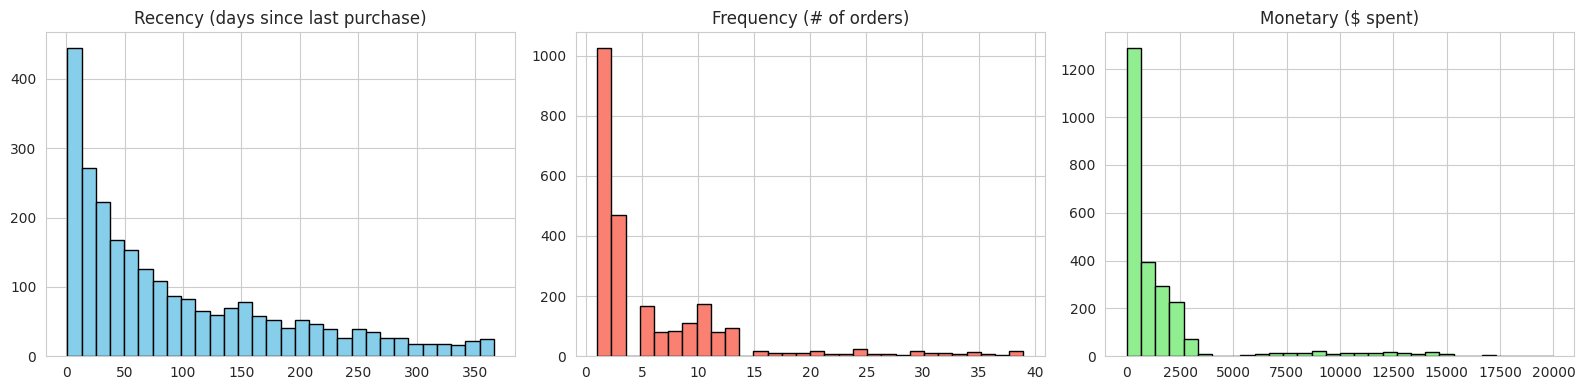

           Recency    Frequency      Monetary
count  2497.000000  2497.000000   2497.000000
mean     94.617141     6.266320   1729.374549
std      91.775100     7.349448   3001.936179
min       1.000000     1.000000      3.660000
25%      21.000000     2.000000    321.050000
50%      60.000000     3.000000    635.620000
75%     149.000000     9.000000   1753.750000
max     366.000000    39.000000  19984.350000


In [8]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rfm['Recency'].hist(ax=axes[0], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Recency (days since last purchase)')
rfm['Frequency'].hist(ax=axes[1], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Frequency (# of orders)')
rfm['Monetary'].hist(ax=axes[2], bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title('Monetary ($ spent)')
plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print(rfm[['Recency','Frequency','Monetary']].describe())

In [9]:
# RFM Scoring (quintile-based)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,C10000,86,7,1325.84,3,4,4,11
1,C10001,179,1,31.75,1,1,1,3
2,C10002,186,2,624.15,1,2,3,6
3,C10003,7,3,407.42,5,3,2,10
4,C10004,94,12,2097.03,2,5,5,12


## 4. K-Means Clustering

In [10]:
# Log-transform skewed features
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
rfm_log = np.log1p(rfm_log)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

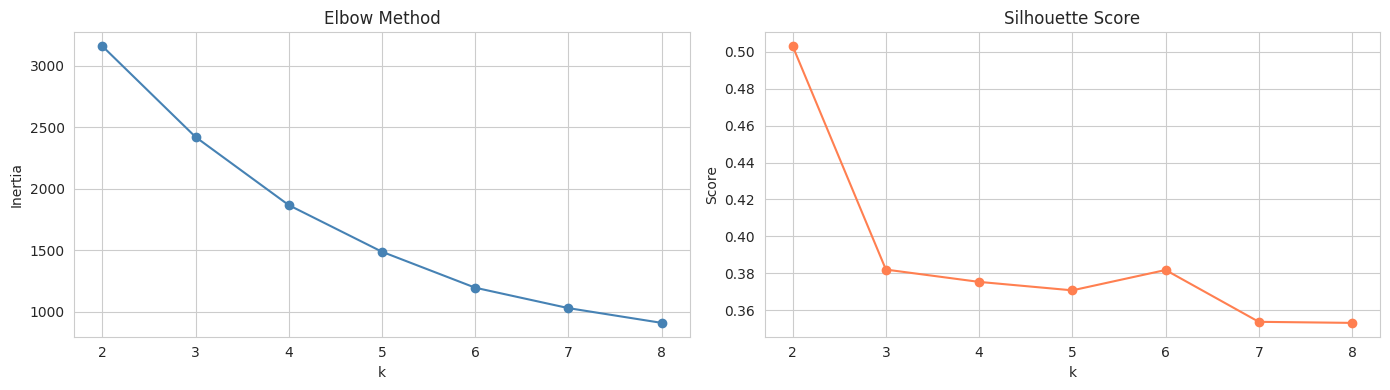

In [11]:
# Elbow method + silhouette
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# Fit final model with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(rfm['Cluster'].value_counts())

Cluster
3    1030
1     619
0     486
2     362
Name: count, dtype: int64


## 5. Segment Profiling

In [13]:
segment_profile = rfm.groupby('Cluster').agg(
    Recency_avg=('Recency', 'mean'),
    Frequency_avg=('Frequency', 'mean'),
    Monetary_avg=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(2)
segment_profile['Revenue_Share_%'] = (rfm.groupby('Cluster')['Monetary'].sum() / rfm['Monetary'].sum() * 100).round(1)
segment_profile

,Recency_avg,Frequency_avg,Monetary_avg,Count,Revenue_Share_%
Cluster,,,,,
0,33.37,2.42,484.44,486,5.5
1,48.28,8.86,1806.40,619,25.9
2,9.63,19.64,7131.28,362,59.8
3,181.23,1.83,371.97,1030,8.9


In [14]:
# Assign business labels based on profile
def label_segment(row):
    if row['Recency_avg'] < 30 and row['Monetary_avg'] > segment_profile['Monetary_avg'].median():
        return 'Champions'
    elif row['Recency_avg'] < 60 and row['Frequency_avg'] > segment_profile['Frequency_avg'].median():
        return 'Loyal Customers'
    elif row['Recency_avg'] > 90:
        return 'At Risk / Lost'
    else:
        return 'Potential Loyalists'

segment_profile['Segment'] = segment_profile.apply(label_segment, axis=1)
segment_profile

,Recency_avg,Frequency_avg,Monetary_avg,Count,Revenue_Share_%,Segment
Cluster,,,,,,
0,33.37,2.42,484.44,486,5.5,Potential Loyalists
1,48.28,8.86,1806.40,619,25.9,Loyal Customers
2,9.63,19.64,7131.28,362,59.8,Champions
3,181.23,1.83,371.97,1030,8.9,At Risk / Lost


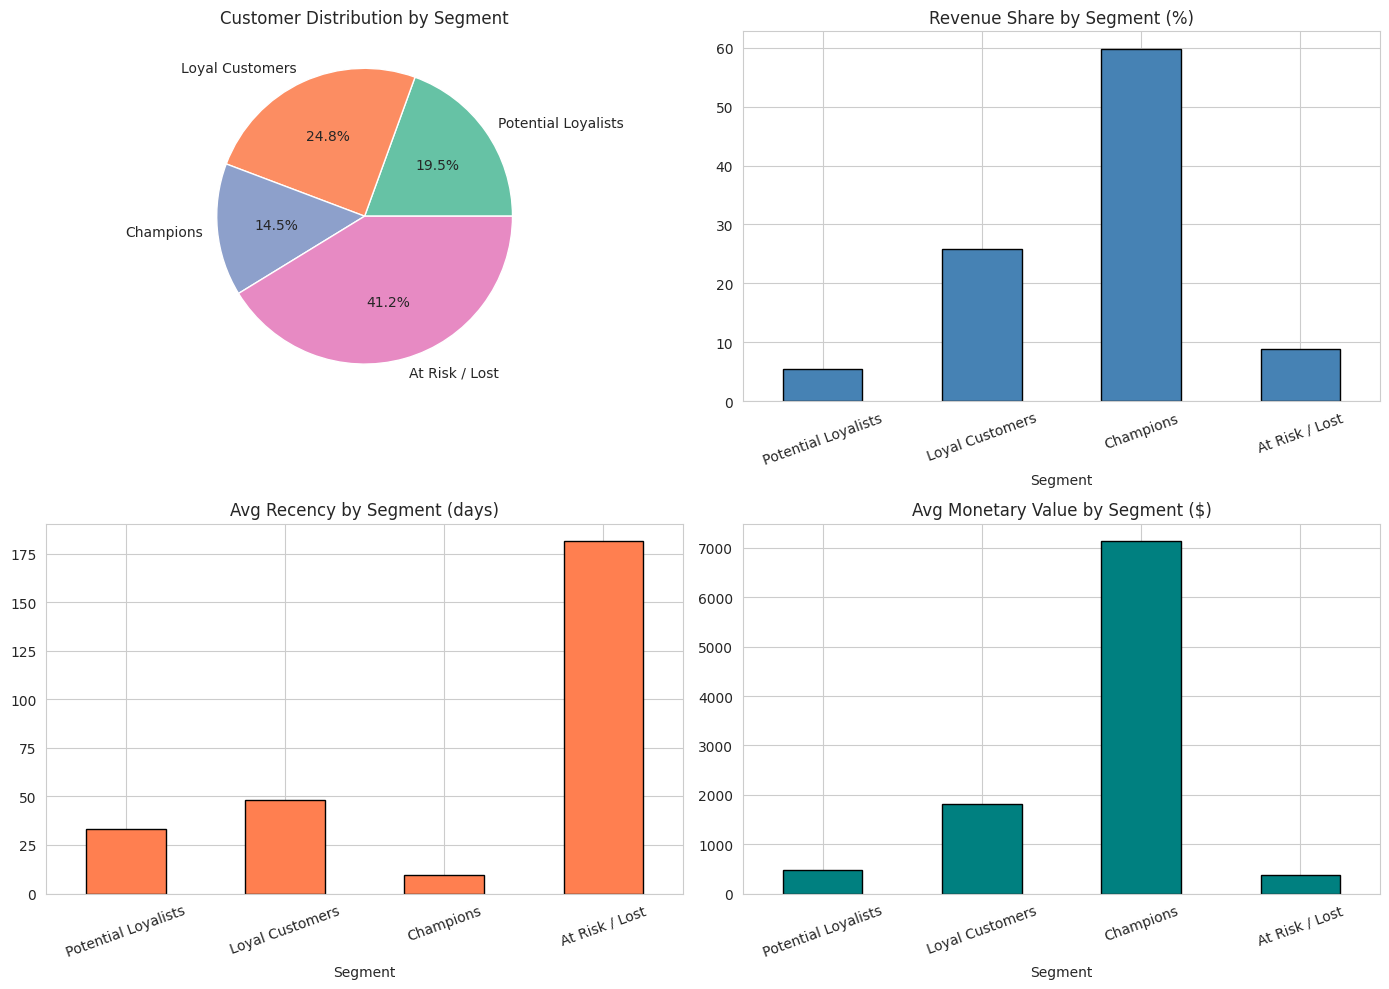

In [15]:
# Visualize segments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segment_profile['Count'].plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%',
                              labels=segment_profile['Segment'], colors=sns.color_palette('Set2'))
axes[0,0].set_title('Customer Distribution by Segment')
axes[0,0].set_ylabel('')

segment_profile.plot(x='Segment', y='Revenue_Share_%', kind='bar', ax=axes[0,1],
                     color='steelblue', edgecolor='black', legend=False)
axes[0,1].set_title('Revenue Share by Segment (%)')
axes[0,1].tick_params(axis='x', rotation=20)

segment_profile.plot(x='Segment', y='Recency_avg', kind='bar', ax=axes[1,0],
                     color='coral', edgecolor='black', legend=False)
axes[1,0].set_title('Avg Recency by Segment (days)')
axes[1,0].tick_params(axis='x', rotation=20)

segment_profile.plot(x='Segment', y='Monetary_avg', kind='bar', ax=axes[1,1],
                     color='teal', edgecolor='black', legend=False)
axes[1,1].set_title('Avg Monetary Value by Segment ($)')
axes[1,1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../outputs/segment_profile.png', dpi=100, bbox_inches='tight')
plt.show()

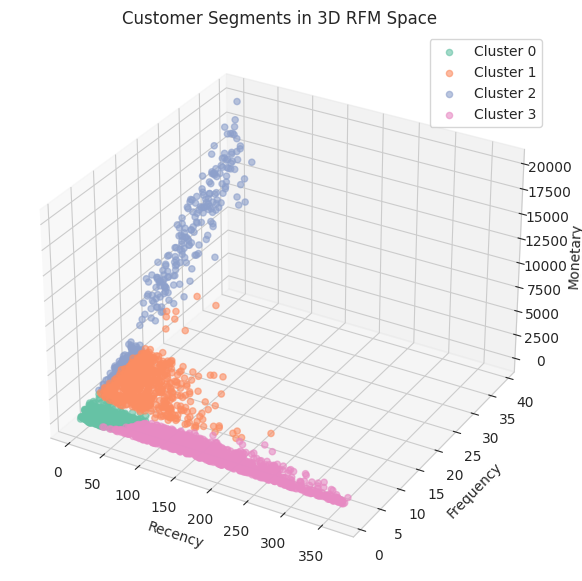

In [16]:
# 3D scatter of segments
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
colors = sns.color_palette('Set2', k)
for c in range(k):
    cluster_data = rfm[rfm['Cluster']==c]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'],
               c=[colors[c]], label=f'Cluster {c}', alpha=0.6, s=20)
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('Customer Segments in 3D RFM Space')
ax.legend()
plt.savefig('../outputs/rfm_3d.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Marketing Strategy Recommendations

| Segment | Strategy |
|---------|----------|
| **Champions** | Reward with VIP perks, early access to new products, loyalty programs. Ask for reviews/referrals. |
| **Loyal Customers** | Upsell premium products, personalized recommendations, exclusive bundles. |
| **Potential Loyalists** | Onboard with welcome series, encourage second purchase via discount, cross-sell complementary items. |
| **At Risk / Lost** | Win-back campaigns with strong offers (20-30% off), survey for feedback, re-engagement email series. |

### Key Findings
- A small group of high-value customers (Champions) generates a disproportionate share of revenue (Pareto principle in action).
- At Risk customers represent the largest re-engagement opportunity.
- Q4 shows the strongest seasonal revenue spike — plan inventory and campaigns accordingly.

### Next Steps
- Deploy segment-specific email campaigns and track conversion lift
- A/B test win-back offers for At Risk segment
- Build a predictive churn model on top of these segments

In [17]:
# Save final RFM table with cluster assignments
rfm.to_csv('../outputs/rfm_segments.csv', index=False)
print('Saved rfm_segments.csv with', len(rfm), 'customers')

Saved rfm_segments.csv with 2497 customers
